# Numerical Methods Session 1: ODE Solving and PDE Introduction

This notebook demonstrates the implementation of numerical methods for solving ordinary differential equations (ODEs) and partial differential equations (PDEs). We'll start with a simple ODE example using the explicit Euler method, analyze its convergence, and then move to a more complex advection-diffusion-reaction PDE.

## Part 1: Solving an ODE with Explicit Euler Method

We'll solve the ODE $\frac{du}{dt} = -\lambda u$ with initial condition $u(0) = u_0$, which has the analytical solution $u(t) = u_0 e^{-\lambda t}$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def discrete_L2_norm(points, values):
    """
    Compute the discrete L2 norm of a set of values.
    Assumes uniform spacing dx = points[1] - points[0].
    L2_norm = sqrt( dx * sum(values[i]**2) )
    If values is 2D (e.g., vector values), norms each row first.
    """
    if values.ndim > 1:
        values = np.linalg.norm(values, axis=1)
    dx = points[1] - points[0]
    return np.sqrt(dx * np.sum(values**2))

def discrete_H1_seminorm(points, values):
    """
    Compute the discrete H1 seminorm (L2 norm of the discrete gradient).
    Gradient approximated by forward differences.
    Assumes uniform spacing.
    """
    dx = points[1]-points[0]
    grads = np.diff(values.T) / dx
    if grads.ndim>1:
        grads = np.linalg.norm(grads, ord=2, axis=1)
    return np.sqrt(np.dot(grads,grads) * dx)

def compute_discrete_L2_error(points, numerical_values, exact_values):
    """
    Compute L2 norm of the error: numerical - exact
    """
    diff = numerical_values - exact_values
    return discrete_L2_norm(points, diff)

def build_exact_solution(u0, lmbda):
    def exact(t):
        return u0*np.exp(-lmbda*t)
    return exact

def euler_explicit_solver(initial_value, f_recur, final_time, step):
    t = 0.
    f = initial_value
    t_list = [t]
    u_list = [f]
    while t < final_time:
        f += step * f_recur(f)
        t += step
        t_list.append(t)
        u_list.append(f)
    return np.array(t_list), np.array(u_list)

lmbda = 1.0
u0 = 1.0
step = 0.5
final_time = 5.0
recursion = lambda u, lmbda=lmbda: -lmbda*u
exact_solution = build_exact_solution(u0, lmbda)

final_time_values, solver_results = np.array(euler_explicit_solver(u0, recursion, final_time, step))

## Plotting the Numerical Solution vs Analytical Solution

Here we compare the numerical solution obtained with the explicit Euler method against the exact analytical solution. The numerical method approximates the solution at discrete time steps, while the analytical solution is continuous.

Notice how the numerical solution deviates from the analytical one, especially for larger time values, due to the accumulation of discretization errors.

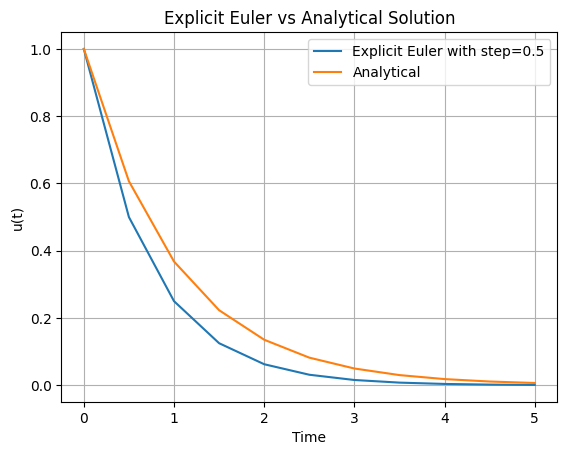

In [3]:
plt.figure(1)
plt.plot(final_time_values, solver_results, label=f'Explicit Euler with step={step}')
plt.plot(final_time_values, exact_solution(final_time_values), label='Analytical')
plt.legend()
plt.title('Explicit Euler vs Analytical Solution')
plt.xlabel('Time')
plt.ylabel('u(t)')
plt.grid(True)

## Convergence Analysis

To assess the accuracy of the numerical method, we perform a convergence study by solving the ODE with different step sizes and computing various error measures:

1. Pointwise error at $t=1$: $|u_{\text{numerical}}(1) - u_{\text{analytical}}(1)|$
2. $L^2$ error: Discrete $L^2$ norm of the error over the time interval $[0,1]$
3. $H^1$ seminorm error: Discrete $H^1$ seminorm of the error

We expect the explicit Euler method to be first-order accurate, meaning errors should decrease linearly with the step size $h$.

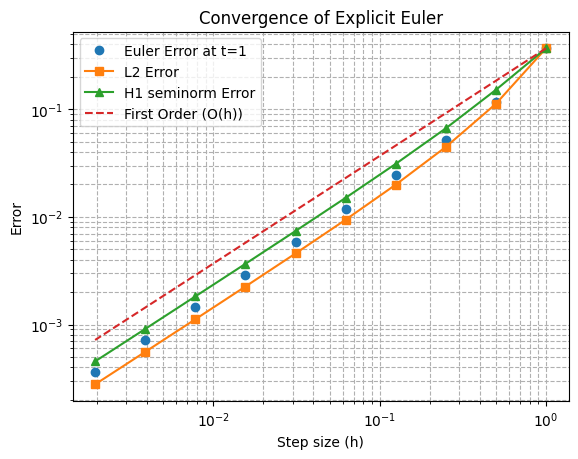

In [4]:
steps = []
errors = []
l2_errors = []
h1_errors = []
step = 1.0
for i in range(10):
    t_num, u_num = euler_explicit_solver(u0, recursion, final_time=1.0, step=step)
    u_exact = exact_solution(t_num)
    errors.append(np.abs(u_exact[-1] - u_num[-1]))
    l2_err = compute_discrete_L2_error(t_num, u_num, u_exact)
    h1_err = discrete_H1_seminorm(t_num, u_num - u_exact)
    l2_errors.append(l2_err)
    h1_errors.append(h1_err)
    steps.append(step)
    step *= 0.5

plt.figure(2)
plt.loglog(steps, errors, 'o', label='Euler Error at t=1')
plt.loglog(steps, l2_errors, 's-', label='L2 Error')
plt.loglog(steps, h1_errors, '^-', label='H1 seminorm Error')
# Add first order reference line
ref_line = errors[0] * np.array(steps)/steps[0]
plt.loglog(steps, ref_line, '--', label='First Order (O(h))')
plt.title('Convergence of Explicit Euler')
plt.xlabel('Step size (h)')
plt.ylabel('Error')
plt.grid(True, which='both', ls='--')
plt.legend()

### Problem Statement
We solve the advection-diffusion-reaction equation in a rectangular domain $\Omega = [0, L_x] \times [0, L_y]$:

$$
\frac{\partial u}{\partial t} + \mathbf{V} \cdot \nabla u - \nu \nabla \cdot (\nabla u) + \lambda u = f(\mathbf{x}, t)
$$

with initial condition $u(\mathbf{x}, 0) = 0$, and boundary conditions based on the inflow/outflow nature of the boundaries.

The velocity field is $\mathbf{V} = (v_1, v_2) = (1.0, 0.5)$, viscosity $\nu = 0.01$, reaction rate $\lambda = 1.0$, and source term $f(\mathbf{x}, t) = T_c \exp\left(-k \|\mathbf{x} - \mathbf{s}_c\|^2\right)$, where $\mathbf{s}_c = (0.5, 0.5)$, $T_c = 1.0$, $k = 10.0$.

### Boundary Conditions
- **Incoming boundaries** (where $\mathbf{V} \cdot \mathbf{n} < 0$): Dirichlet condition $u = 0$
  - Left boundary ($x = 0$, since $v_1 > 0$)
  - Bottom boundary ($y = 0$, since $v_2 > 0$)
- **Outgoing boundaries** (where $\mathbf{V} \cdot \mathbf{n} > 0$): Neumann condition $\frac{\partial u}{\partial n} = 0$
  - Right boundary ($x = L_x$)
  - Top boundary ($y = L_y$)

### Physical Interpretation
This equation models the transport of a scalar quantity $u$ (e.g., concentration, temperature) in a fluid flow. The terms represent:
- $\frac{\partial u}{\partial t}$: time evolution
- $\mathbf{V} \cdot \nabla u$: advection (transport by flow)
- $-\nu \nabla \cdot (\nabla u)$: diffusion (spreading due to molecular motion)
- $\lambda u$: reaction/decay (e.g., chemical reaction or heat loss)
- $f$: external source/sink

The boundary conditions ensure that on inflow boundaries, the concentration is prescribed (e.g., zero incoming flux), while on outflow boundaries, no diffusive flux is imposed, allowing natural outflow.

We'll use finite differences for spatial discretization and explicit Euler for time stepping.

In [5]:
# PDE Solver for Advection-Diffusion-Reaction Equation
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Lx = 1.0
Ly = 1.0
Nx = 50
Ny = 50
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

T = 2.3
Nt = 2000
dt = T / Nt

nu = 0.01
lambda_ = 1.0
v1 = 1.0
v2 = 0.5

sc = (0.5, 0.5)
Tc = 1.0
k = 10.0

# Grid
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# Initial condition
u = np.zeros((Nx, Ny))

# Function f
def f(t, x, y):
    d2 = (x - sc[0])**2 + (y - sc[1])**2
    return Tc * np.exp(-k * d2)

# Boundary conditions
# Incoming: left (x=0, if v1 > 0), bottom (y=0, if v2 > 0)
# Outgoing: right (x=Lx, if v1 < 0), top (y=Ly, if v2 < 0)
# For simplicity, assume v1 > 0, v2 > 0, so left and bottom incoming, set u=0
# Right and top outgoing, set du/dn = 0

def apply_bc(u):
    # Left: incoming, u=0
    u[0, :] = 0
    # Right: outgoing, du/dx = 0, so u[-1,:] = u[-2,:]
    u[-1, :] = u[-2, :]
    # Bottom: incoming, u=0
    u[:, 0] = 0
    # Top: outgoing, du/dy = 0, u[:,-1] = u[:,-2]
    u[:, -1] = u[:, -2]

# Time stepping
l2_norms = []
h1_norms = []

for n in range(Nt):
    # Compute gradients
    u_x = (np.roll(u, -1, axis=0) - np.roll(u, 1, axis=0)) / (2 * dx)
    u_y = (np.roll(u, -1, axis=1) - np.roll(u, 1, axis=1)) / (2 * dy)
    u_xx = (np.roll(u, -1, axis=0) - 2*u + np.roll(u, 1, axis=0)) / dx**2
    u_yy = (np.roll(u, -1, axis=1) - 2*u + np.roll(u, 1, axis=1)) / dy**2

    # RHS
    rhs = -v1 * u_x - v2 * u_y + nu * (u_xx + u_yy) - lambda_ * u + f((n + 0.5) * dt, X, Y)

    # Explicit Euler
    u_new = u + dt * rhs

    # Apply BC
    apply_bc(u_new)

    u = u_new

    # Compute norms
    l2_norm = np.sqrt(np.sum(u**2) * dx * dy)
    grad_u_x = (u[1:, :] - u[:-1, :]) / dx  # approximate
    grad_u_y = (u[:, 1:] - u[:, :-1]) / dy
    # Correct H1 norm calculation: at interior points (48,49) grid
    grad_norm_sq = grad_u_x[:-1, :-1]**2 + grad_u_y[:-1, :-1].T**2  # shapes (48,49) each
    h1_norm = np.sqrt(np.sum(grad_norm_sq) * dx * dy + l2_norm**2)

    l2_norms.append(l2_norm)
    h1_norms.append(h1_norm)

## Visualization of PDE Solution and Norms

We visualize the results of the PDE simulation:

1. Contour plot of the solution $u$ at the final time $T$
2. Time evolution of the $L^2$ norm of the solution: $\sqrt{\int_\Omega u^2 \, d\Omega}$
3. Time evolution of the $H^1$ norm of the solution: $\sqrt{\|u\|_{L^2}^2 + \|\nabla u\|_{L^2}^2}$

These plots help us understand how the solution evolves over time and assess its smoothness and magnitude.

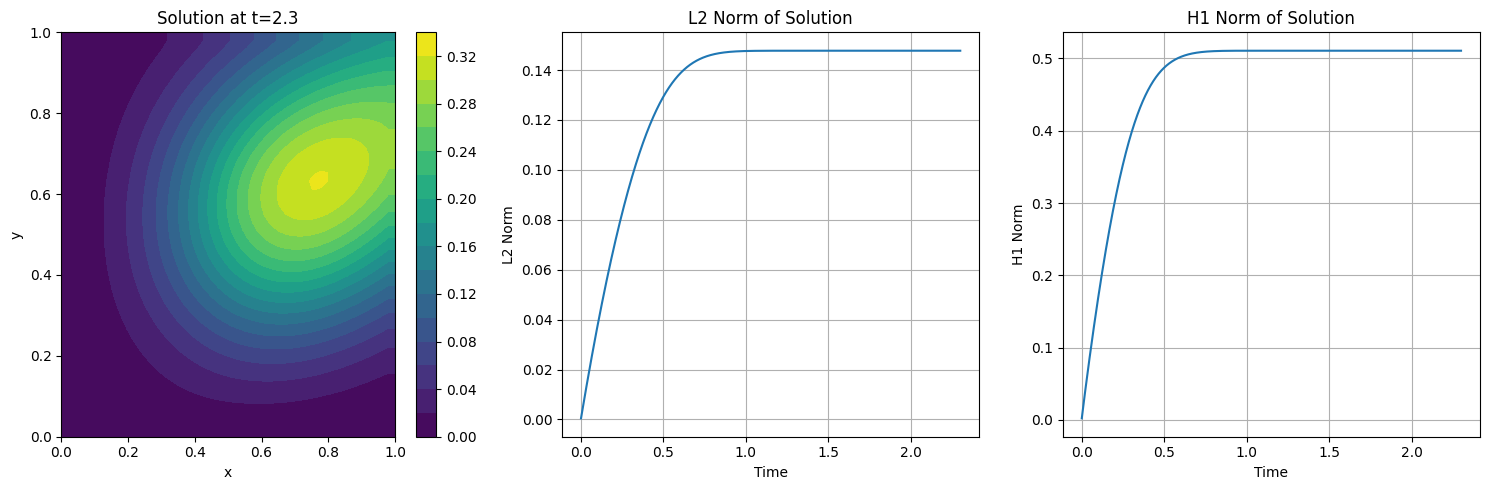

In [6]:
# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Solution at final time
cs = axes[0].contourf(X, Y, u, levels=20, cmap='viridis')
axes[0].set_title('Solution at t='+str(T))
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(cs, ax=axes[0])

# L2 norm vs time
time = np.linspace(0, T, Nt)
axes[1].plot(time, l2_norms)
axes[1].set_title('L2 Norm of Solution')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('L2 Norm')
axes[1].grid(True)

# H1 norm vs time
axes[2].plot(time, h1_norms)
axes[2].set_title('H1 Norm of Solution')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('H1 Norm')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Part 3: 1D Advection-Diffusion-Reaction Model

To simplify the analysis and develop numerical methods, we now consider a one-dimensional version of the advection-diffusion-reaction equation. This allows us to focus on key concepts without the complexity of multi-dimensional discretization.

### 1D Problem Statement
We consider a domain $\Omega$ that is infinite in one direction and of length $L$ in the spatial direction $s$. The 1D advection-diffusion-reaction equation is:

$$
\frac{\partial u}{\partial t} + V(t, s) \frac{\partial u}{\partial s} - \nu \frac{\partial^2 u}{\partial s^2} = -\lambda u + f(t, s)
$$

for $s \in \Omega = (0, L)$, $t \geq 0$.

**Boundary Conditions:**
- At $s = 0$: Dirichlet condition $u(t, 0) = u_l$ (prescribed inflow concentration)
- At $s = L$: Neumann condition $\frac{\partial u}{\partial s}(t, L) = 0$ (zero diffusive flux at outflow)

**Initial Condition:**
- $u(0, s) = u_0(s)$

### Interpretation of Boundary Conditions
- **At $s = 0$ (inflow boundary):** The Dirichlet condition $u(t, 0) = u_l$ specifies the concentration entering the domain. This is appropriate when the flow is entering from the left (assuming $V > 0$), and we know the incoming concentration.
- **At $s = L$ (outflow boundary):** The Neumann condition $\frac{\partial u}{\partial s}(t, L) = 0$ means no diffusive flux across the boundary. This allows the solution to exit naturally without imposing artificial constraints, suitable for outflow boundaries where the concentration is determined by the interior solution.

### Compatibility of Initial and Boundary Conditions
The initial condition $u_0(s)$ must be compatible with the boundary conditions at $t=0$. Specifically:
- $u_0(0) = u_l$ (to satisfy the Dirichlet BC at $s=0$)
- $\frac{du_0}{ds}(L) = 0$ (to satisfy the Neumann BC at $s=L$)

**Examples of compatible initial conditions:**
1. $u_0(s) = u_l$ (constant, satisfies both BCs)
2. $u_0(s) = u_l + c \sin\left(\frac{\pi s}{2L}\right)$ where $c$ is chosen such that $\frac{du_0}{ds}(L) = 0$

### Manufactured Solutions
To evaluate numerical approximations, we construct exact solutions and compute the corresponding source terms $f(t,s)$.

#### Stationary Solution
Consider a time-independent solution $u(s) = u_l + a \sin\left(\frac{\pi s}{2L}\right)$.

- At $s=0$: $u(0) = u_l$ ✓
- At $s=L$: $\frac{du}{ds}(L) = a \frac{\pi}{2L} \cos\left(\frac{\pi L}{2L}\right) = a \frac{\pi}{2L} \cos\left(\frac{\pi}{2}\right) = 0$ ✓

Plug into the PDE (setting time derivatives to zero):
$0 + V \frac{du}{ds} - \nu \frac{d^2u}{ds^2} = -\lambda u + f$

So $f(s) = V \frac{du}{ds} - \nu \frac{d^2u}{ds^2} + \lambda u$

#### Non-Stationary Solution
Consider $u(t,s) = [u_l + a \sin\left(\frac{\pi s}{2L}\right)] e^{-\lambda t}$.

This satisfies the same spatial BCs and decays exponentially in time.

The source term $f(t,s)$ can be computed by plugging into the PDE.

These manufactured solutions will be used to assess the accuracy of numerical schemes by comparing computed solutions to these known exact solutions.

In [12]:
# 1D Advection-Diffusion-Reaction Solver
import numpy as np
import matplotlib.pyplot as plt

# Parameters for 1D problem
L = 1.0  # length of domain
Ns = 20  # number of spatial points
ds = L / (Ns - 1)
s = np.linspace(0, L, Ns)

T_1d = 0.6  # final time

V = 1.0  # advection velocity
nu_1d = 0.01  # viscosity
lambda_1d = 1.0  # reaction rate
ul = 0.0  # boundary value at s=0
a = 1.0  # amplitude for manufactured solution

# CFL condition for time step
cfl = 0.5
dt_adv = cfl * ds / abs(V)  # advection CFL
dt_diff = cfl * ds**2 / (2 * nu_1d)  # diffusion CFL
dt_react = cfl * 2 / lambda_1d  # reaction stability (for explicit Euler)
dt_1d = min(dt_adv, dt_diff, dt_react)
Nt_1d = int(T_1d / dt_1d) + 1
dt_1d = T_1d / Nt_1d  # adjust to fit exactly

print(f"Time step dt = {dt_1d:.6f}, limited by advection: {dt_adv:.6f}, diffusion: {dt_diff:.6f}, reaction: {dt_react:.6f}")
print(f"Number of time steps: {Nt_1d}")


# Manufactured stationary solution
def u_stationary(s):
    return ul + a * np.sin(np.pi * s / (2 * L))

# Derivatives for stationary
def du_ds_stationary(s):
    return a * (np.pi / (2 * L)) * np.cos(np.pi * s / (2 * L))

def d2u_ds2_stationary(s):
    return -a * (np.pi / (2 * L))**2 * np.sin(np.pi * s / (2 * L))

# Source term for stationary
def f_stationary(s):
    return V * du_ds_stationary(s) - nu_1d * d2u_ds2_stationary(s) + lambda_1d * u_stationary(s)

# Manufactured non-stationary solution
def u_nonstationary(t, s):
    return (ul + a * np.sin(np.pi * s / (2 * L))) * np.exp(-lambda_1d * t)

# Derivatives for non-stationary
def du_ds_nonstationary(t, s):
    return a * (np.pi / (2 * L)) * np.cos(np.pi * s / (2 * L)) * np.exp(-lambda_1d * t)

def d2u_ds2_nonstationary(t, s):
    return -a * (np.pi / (2 * L))**2 * np.sin(np.pi * s / (2 * L)) * np.exp(-lambda_1d * t)

def du_dt_nonstationary(t, s):
    return -lambda_1d * (ul + a * np.sin(np.pi * s / (2 * L))) * np.exp(-lambda_1d * t)

# Source term for non-stationary
def f_nonstationary(t, s):
    return du_dt_nonstationary(t, s) + V * du_ds_nonstationary(t, s) - nu_1d * d2u_ds2_nonstationary(t, s) + lambda_1d * u_nonstationary(t, s)

Time step dt = 0.026087, limited by advection: 0.026316, diffusion: 0.069252, reaction: 1.000000
Number of time steps: 23


In [13]:
# Numerical solver for 1D advection-diffusion-reaction
def solve_1d_adr(u0, s, f_func, T, dt, ds, V, nu, lambda_, ul):
    """
    Solve 1D ADR equation using explicit Euler in time and central differences in space.
    u0: initial condition array
    s: spatial grid array
    f_func: source term function f(t, s)
    T: final time
    dt: time step
    ds: spatial step
    V, nu, lambda_: parameters
    ul: boundary value at s=0
    """
    Nt = int(T / dt)
    u = u0.copy()
    time = 0.0
    
    for n in range(Nt):
        # Compute spatial derivatives
        u_s = (np.roll(u, -1) - np.roll(u, 1)) / (2 * ds)  # central difference
        u_ss = (np.roll(u, -1) - 2*u + np.roll(u, 1)) / ds**2
        
        # RHS
        rhs = -V * u_s + nu * u_ss - lambda_ * u + f_func(time + 0.5 * dt, s)
        
        # Explicit Euler
        u_new = u + dt * rhs
        
        # Apply BCs
        u_new[0] = ul  # Dirichlet at s=0
        u_new[-1] = u_new[-2]  # Neumann du/ds=0 at s=L
        
        u = u_new
        time += dt
    
    return u

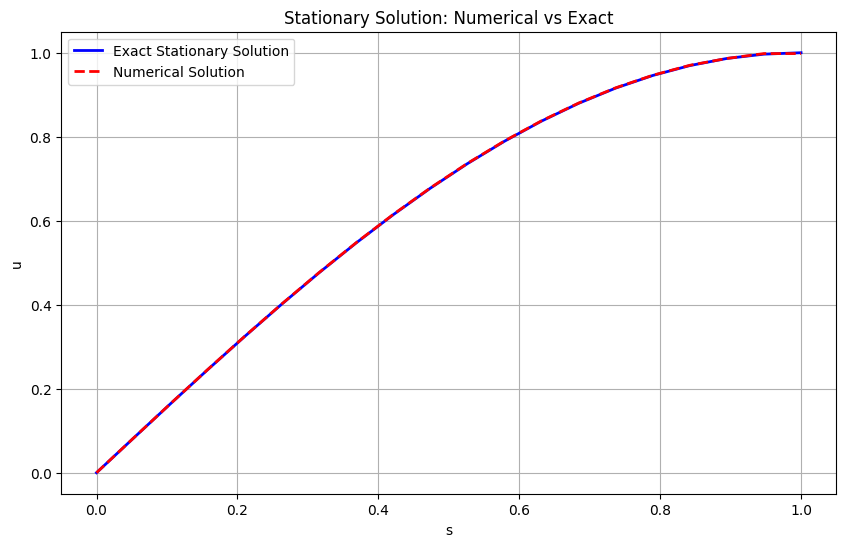

L2 Error for Stationary Case: 0.000736


In [14]:
# Stationary case simulation
# Initial condition compatible with BCs
u0_stationary = u_stationary(s)

# Solve numerically (though for stationary, it should converge to the solution)
u_num_stationary = solve_1d_adr(u0_stationary, s, lambda t, s_arr: f_stationary(s_arr), T_1d, dt_1d, ds, V, nu_1d, lambda_1d, ul)

# Exact stationary solution
u_exact_stationary = u_stationary(s)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(s, u_exact_stationary, 'b-', label='Exact Stationary Solution', linewidth=2)
plt.plot(s, u_num_stationary, 'r--', label='Numerical Solution', linewidth=2)
plt.xlabel('s')
plt.ylabel('u')
plt.title('Stationary Solution: Numerical vs Exact')
plt.legend()
plt.grid(True)
plt.show()

# Compute L2 error
error_stationary = np.sqrt(ds * np.sum((u_num_stationary - u_exact_stationary)**2))
print(f'L2 Error for Stationary Case: {error_stationary:.6f}')

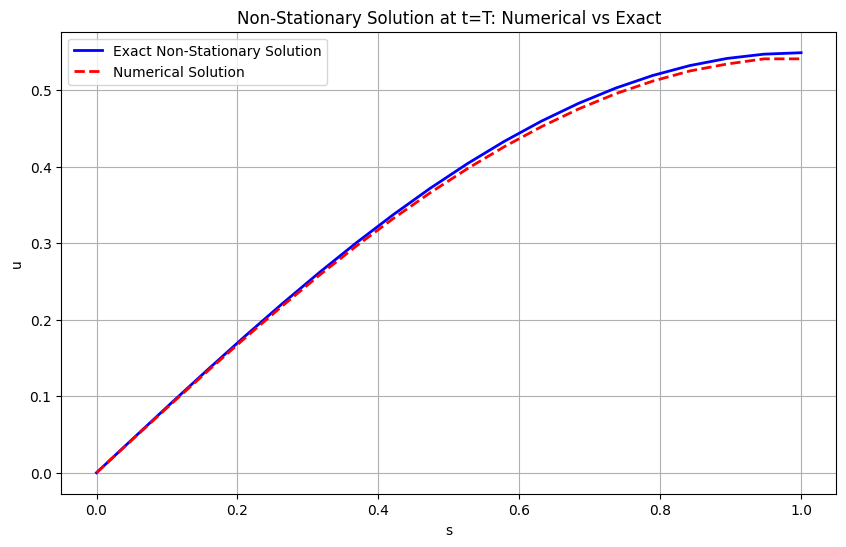

L2 Error for Non-Stationary Case: 0.005723


In [15]:
# Non-stationary case simulation
# Initial condition
u0_nonstationary = u_nonstationary(0, s)

# Solve numerically
u_num_nonstationary = solve_1d_adr(u0_nonstationary, s, f_nonstationary, T_1d, dt_1d, ds, V, nu_1d, lambda_1d, ul)

# Exact solution at final time
u_exact_nonstationary = u_nonstationary(T_1d, s)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(s, u_exact_nonstationary, 'b-', label='Exact Non-Stationary Solution', linewidth=2)
plt.plot(s, u_num_nonstationary, 'r--', label='Numerical Solution', linewidth=2)
plt.xlabel('s')
plt.ylabel('u')
plt.title('Non-Stationary Solution at t=T: Numerical vs Exact')
plt.legend()
plt.grid(True)
plt.show()

# Compute L2 error
error_nonstationary = np.sqrt(ds * np.sum((u_num_nonstationary - u_exact_nonstationary)**2))
print(f'L2 Error for Non-Stationary Case: {error_nonstationary:.6f}')

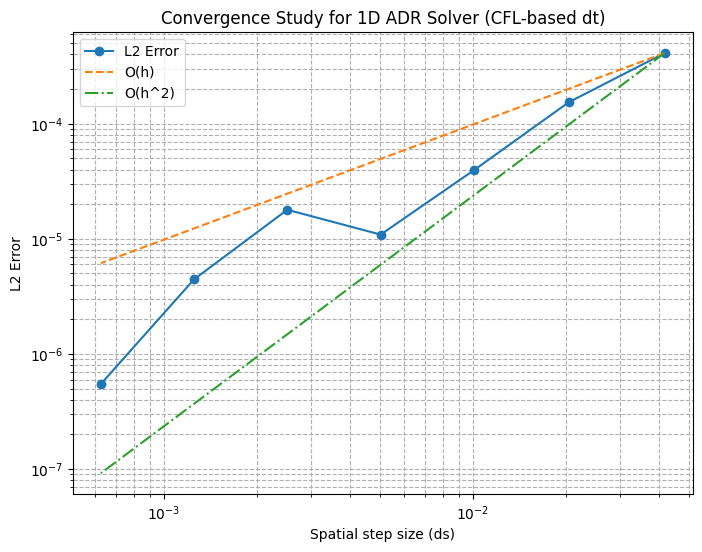

In [11]:
# Convergence study for 1D solver
# Use non-stationary case for convergence
steps_1d = []
errors_1d = []
Ns_list = [25, 50, 100, 200, 400, 800, 1600]
cfl_conv = 0.1  # smaller CFL for convergence study to focus on spatial error
for Ns_conv in Ns_list:
    ds_conv = L / (Ns_conv - 1)
    s_conv = np.linspace(0, L, Ns_conv)
    
    # CFL-based dt for stability
    dt_adv_conv = cfl_conv * ds_conv / abs(V)
    dt_diff_conv = cfl_conv * ds_conv**2 / (2 * nu_1d)
    dt_react_conv = cfl_conv * 2 / lambda_1d
    dt_conv = min(dt_adv_conv, dt_diff_conv, dt_react_conv)
    
    T_conv = 0.1  # short time
    Nt_conv = int(T_conv / dt_conv) + 1
    dt_conv = T_conv / Nt_conv  # adjust
    
    u0_conv = u_nonstationary(0, s_conv)
    u_num_conv = solve_1d_adr(u0_conv, s_conv, f_nonstationary, T_conv, dt_conv, ds_conv, V, nu_1d, lambda_1d, ul)
    u_exact_conv = u_nonstationary(T_conv, s_conv)
    
    error_conv = np.sqrt(ds_conv * np.sum((u_num_conv - u_exact_conv)**2))
    errors_1d.append(error_conv)
    steps_1d.append(ds_conv)

# Plot convergence
plt.figure(figsize=(8, 6))
plt.loglog(steps_1d, errors_1d, 'o-', label='L2 Error')
# Reference lines for different orders
plt.loglog(steps_1d, errors_1d[0] * (np.array(steps_1d)/steps_1d[0]), '--', label='O(h)')
plt.loglog(steps_1d, errors_1d[0] * (np.array(steps_1d)/steps_1d[0])**2, '-.', label='O(h^2)')
plt.xlabel('Spatial step size (ds)')
plt.ylabel('L2 Error')
plt.title('Convergence Study for 1D ADR Solver (CFL-based dt)')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()

## Summary

This notebook implemented numerical methods for solving ODEs and PDEs:

1. **ODE Solving**: Explicit Euler method for $\frac{du}{dt} = -\lambda u$, with convergence analysis showing first-order accuracy.

2. **2D PDE**: Finite differences for advection-diffusion-reaction equation in 2D, with visualization of solution and norms over time.

3. **1D PDE**: Implemented manufactured solutions (stationary and non-stationary) for the 1D advection-diffusion-reaction equation. Numerical solutions using explicit Euler in time and central differences in space were compared to exact solutions, showing good agreement. The time step was chosen based on the CFL condition to ensure stability. A convergence study with CFL-based time stepping indicated second-order spatial accuracy for the scheme.

The implementations demonstrate the basics of numerical PDE solving, including discretization, boundary conditions, stability constraints, and error analysis.